<a href="https://colab.research.google.com/github/personallypetra/Grand_Challenge-/blob/Wind-%26-Factories/Air_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Air Quality Data Inspection


In [5]:
import pandas as pd

base_url = "https://raw.githubusercontent.com/personallypetra/Grand_Challenge-/main/data_petra/"

files = [
    "DataExtract 4.csv",
    "DataExtract 5.csv",
    "DataExtract 6.csv",
    "DataExtract 7.csv"
]

dfs = []

for file in files:
    url = base_url + file.replace(" ", "%20")
    df = pd.read_csv(url)
    dfs.append(df)

df_stats = pd.concat(dfs, ignore_index=True)


## 1. Basic Structure

In [6]:
print(f"Shape: {df_stats.shape[0]:,} rows x {df_stats.shape[1]} columns")
print(f"\nData types:")
print(df_stats.dtypes)


Shape: 2,706 rows x 27 columns

Data types:
Country                                                            object
Air Quality Network                                                object
Air Quality Network Name                                           object
Air Quality Station EoI Code                                       object
Air Quality Station Name                                           object
Sampling Point Id                                                  object
Air Pollutant                                                      object
Air Pollutant Description                                          object
Data Aggregation Process Id                                        object
Data Aggregation Process                                           object
Year                                                                int64
Air Pollution Level                                               float64
Unit Of Air Pollution Level                                        o

## 2. Summary Statistics

- numerical and categorical


In [9]:

print(df_stats.describe())

df_stats.describe(include="object")

              Year  Air Pollution Level  Data Coverage  Verification  \
count  2706.000000          2706.000000    2706.000000        2706.0   
mean   2022.484479           821.140721      94.674523           1.0   
std       1.118133          3809.418096       3.518019           0.0   
min    2021.000000            -1.992000      83.840000           1.0   
25%    2021.000000             0.672250      92.900000           1.0   
50%    2022.000000            25.560000      94.810000           1.0   
75%    2023.000000            85.398000      97.605000           1.0   
max    2024.000000         36627.117000     100.000000           1.0   

         Longitude     Latitude     Altitude  City Population  
count  2706.000000  2706.000000  2706.000000           2706.0  
mean     12.504233    41.906535    33.359941        2808293.0  
std       0.036858     0.031844    12.110450              0.0  
min      12.447600    41.857700    17.000000        2808293.0  
25%      12.469600    41.883100

,Country,Air Quality Network,Air Quality Network Name,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Air Pollutant,Air Pollutant Description,Data Aggregation Process Id,Data Aggregation Process,Unit Of Air Pollution Level,Air Quality Station Type,Air Quality Station Area,City,City Code,Source Of Data Flow,Calculation Time,Link to raw data (only E1a/validated data from AQ e-Reporting),Observation Frequency
count,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706,2706
unique,1,1,1,10,10,55,11,11,51,50,3,2,1,1,1,1,51,55,1
top,Italy,NET.IT112A,Regione Lazio,IT0953A,VILLA ADA,SPO.IT1835A_7_UV-P_2006-12-06_00:00:00,NO2,Nitrogen dioxide (air),P1Y-day-per50,1 year 50 %ile of daily values in a year,ug/m3,Background,Urban,Roma ...,IT001C1 ...,E1a/validated data AQ e-Reporting,07/03/2026 22:59:18,https://eeadmz1batchservice02.blob.core.window...,hour
freq,2706,2706,2706,528,528,116,760,760,218,218,2206,1830,2706,2706,2706,2706,218,116,2706


## 3. Missing data

In [10]:
nulls = df_stats.isna().sum()
null_pct = (df_stats.isna().sum() / len(df_stats) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())




                                                                count  percent
Country                                                             0      0.0
Air Quality Network                                                 0      0.0
Air Quality Network Name                                            0      0.0
Air Quality Station EoI Code                                        0      0.0
Air Quality Station Name                                            0      0.0
Sampling Point Id                                                   0      0.0
Air Pollutant                                                       0      0.0
Air Pollutant Description                                           0      0.0
Data Aggregation Process Id                                         0      0.0
Data Aggregation Process                                            0      0.0
Year                                                                0      0.0
Air Pollution Level                                 

## 4. Key Distributions

In [11]:
print("\nPollutants:")
print(df_stats["Air Pollutant"].value_counts())

print("\nYear distribution:")
print(df_stats["Year"].value_counts().sort_index())

print("\nStation Names:")
print(df_stats["Air Quality Station Name"].value_counts())




Pollutants:
Air Pollutant
NO2               760
O3                696
NOX as NO2        320
NO                280
SO2               126
CO                104
C6H5-CH3           84
C6H5-C2H5          84
C6H6               84
m,p-C6H4(CH3)2     84
o-C6H4-(CH3)2      84
Name: count, dtype: int64

Year distribution:
Year
2021    687
2022    687
2023    666
2024    666
Name: count, dtype: int64

Station Names:
Air Quality Station Name
VILLA ADA            528
FERMI                328
BUFALOTTA            294
C.SO FRANCIA         276
CIPRO                252
CINECITTA            252
L.GO PERESTRELLO     252
ARENULA              252
L.GO MAGNA GRECIA    136
TIBURTINA            136
Name: count, dtype: int64


### Pollutant frequency

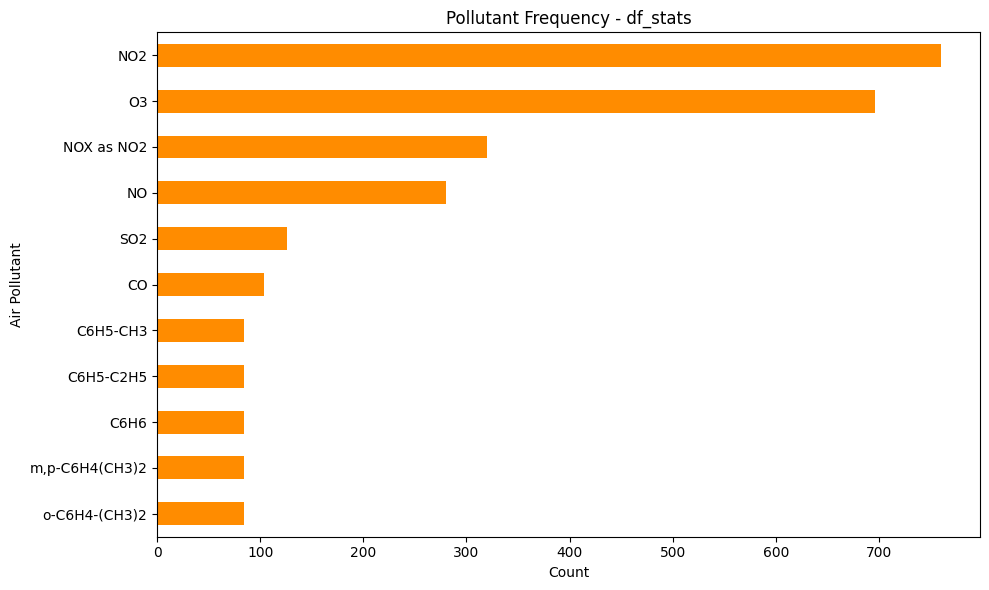

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
df_stats["Air Pollutant"].value_counts().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Pollutant Frequency - df_stats")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Records per station

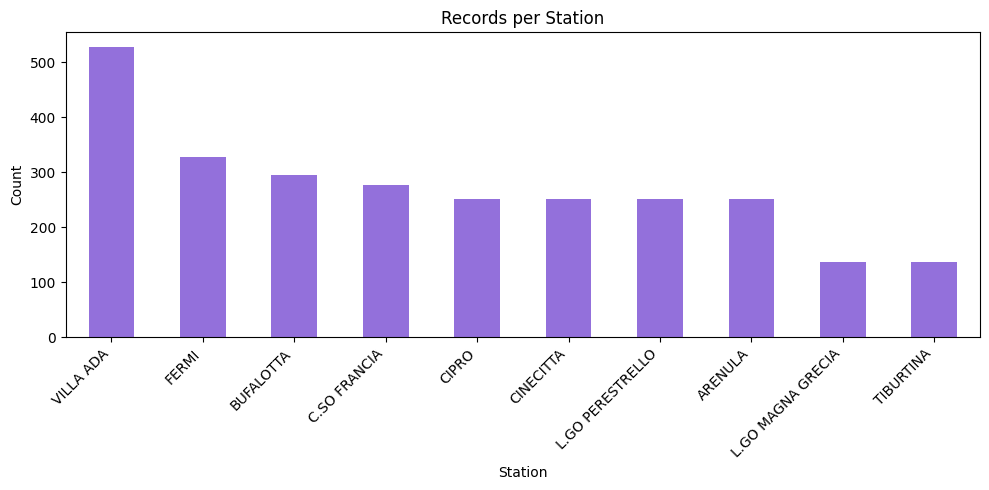

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
df_stats["Air Quality Station Name"].value_counts().plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("Records per Station")
ax.set_xlabel("Station")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

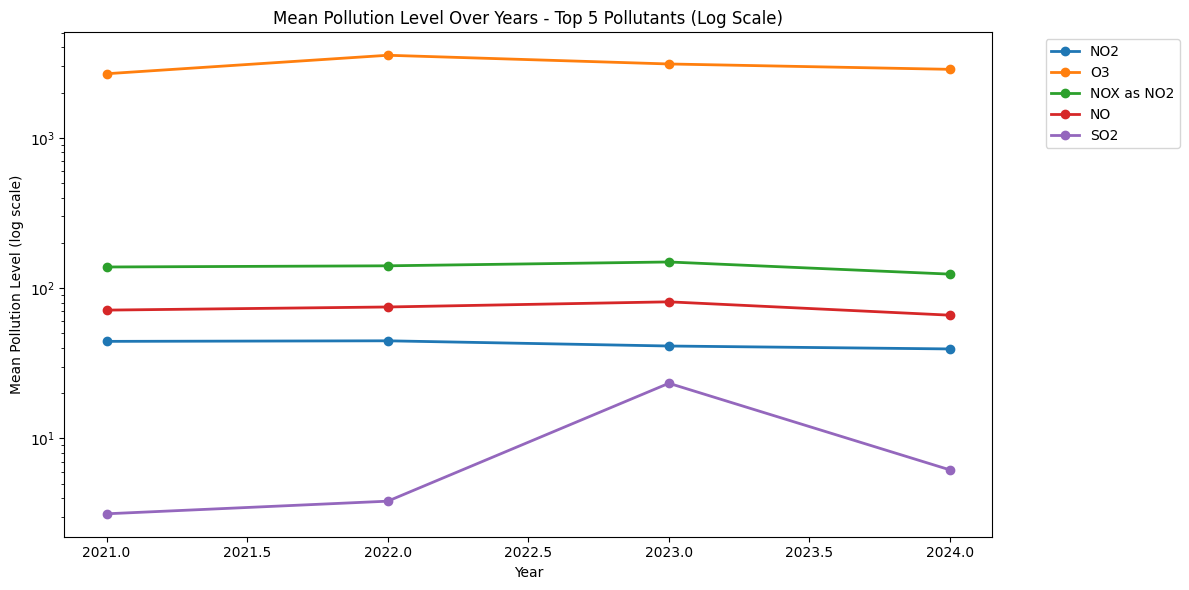

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
for poll in df_stats["Air Pollutant"].value_counts().head(5).index:
    sub = df_stats[df_stats["Air Pollutant"] == poll].groupby("Year")["Air Pollution Level"].mean()
    ax.plot(sub.index, sub.values, marker="o", linewidth=2, label=poll)
ax.set_yscale("log")
ax.set_title("Mean Pollution Level Over Years - Top 5 Pollutants (Log Scale)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Pollution Level (log scale)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [18]:
%%capture
!pip install contextily

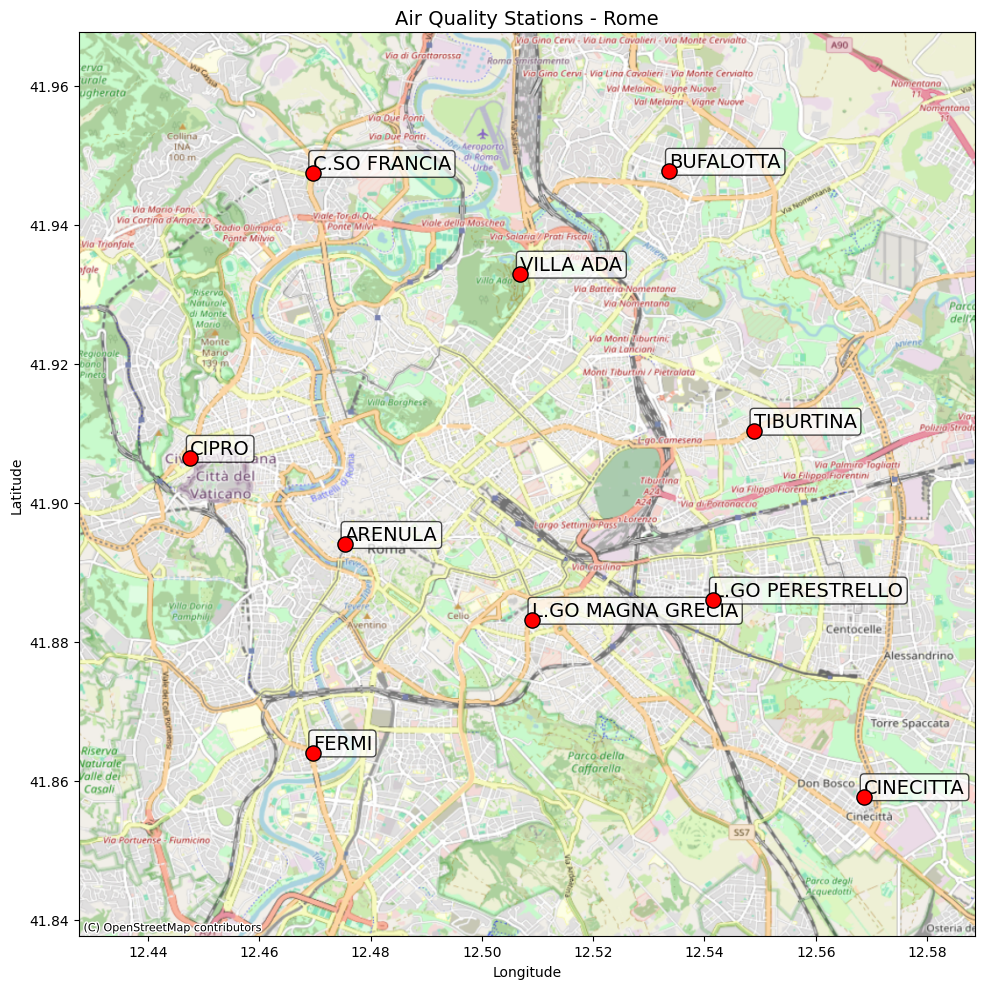

In [19]:
import contextily as ctx
import matplotlib.pyplot as plt

stations = df_stats[["Air Quality Station Name", "Latitude", "Longitude"]].drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(stations["Longitude"], stations["Latitude"], s=120, c="red", zorder=5, edgecolors="black")

for _, row in stations.iterrows():
    ax.annotate(row["Air Quality Station Name"],
                (row["Longitude"], row["Latitude"]),
                fontsize=14, ha="left", va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

# Add some padding around the points
pad = 0.02
ax.set_xlim(stations["Longitude"].min() - pad, stations["Longitude"].max() + pad)
ax.set_ylim(stations["Latitude"].min() - pad, stations["Latitude"].max() + pad)

# Add the real map as background
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Air Quality Stations - Rome", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## Zero Values & Duplicates

In [21]:
numeric_cols = df_stats.select_dtypes(include="number").columns
for col in numeric_cols:
    zero_count = (df_stats[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} zeros ({zero_count/len(df_stats)*100:.2f}%)")
print(f"Exact duplicate rows: {df_stats.duplicated().sum()}")



  Air Pollution Level: 424 zeros (15.67%)
Exact duplicate rows: 0


## Data Quality SUmmary

In [22]:
print(f"  Total rows: {len(df_stats):,}")
print(f"  Columns: {df_stats.shape[1]}")
print(f"  Columns with nulls: {(df_stats.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {df_stats.duplicated().sum()}")
print(f"  Unique stations: {df_stats['Air Quality Station Name'].nunique()}")
print(f"  Unique sampling points: {df_stats['Sampling Point Id'].nunique()}")
print(f"  Unique pollutants: {df_stats['Air Pollutant'].nunique()}")
print(f"  Year range: {df_stats['Year'].min()} - {df_stats['Year'].max()}")
print(f"  Pollution Level range: {df_stats['Air Pollution Level'].min()} - {df_stats['Air Pollution Level'].max()}")

  Total rows: 2,706
  Columns: 27
  Columns with nulls: 0
  Exact duplicates: 0
  Unique stations: 10
  Unique sampling points: 55
  Unique pollutants: 11
  Year range: 2021 - 2024
  Pollution Level range: -1.992 - 36627.117


# Air quality stats data cleaning


Dropping:
- `Country` column — all values are Italy, no information gained*   List item

- `Air Quality Network Name` — all values are "Regione Lazio", no variation

- `Air Quality Network` — same network for all stations (NET.IT112A), no variation

-`Observation Frequency` — same value for all rows (hourly)

-`Source Of Data Flow` — same source for all rows

-`City Code` — redundant identifier, city name is sufficient

-`City Population` — constant value across all rows, no variation

-`Air Quality Station Area` — all stations are Urban, no variation

-`Air Quality Station EoI Code` — redundant, same information as Station Name

-`Data Coverage` — not needed for analysis

-`Verification` — same verification status across rows, no variation


In [23]:

df_stats = df_stats.drop(columns=[
    "Country",
    "Air Quality Network Name",
    "Air Quality Network",
    "Observation Frequency",
    "Source Of Data Flow",
    "City Code",
    "City Population",
    "Air Quality Station Area",
    "Air Quality Station EoI Code",
    "Air Quality Station Type",
    "Data Coverage",
    "Verification",
    "Calculation Time",
    "City"
])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

Remaining columns: 14
['Air Quality Station Name', 'Sampling Point Id', 'Air Pollutant', 'Air Pollutant Description', 'Data Aggregation Process Id', 'Data Aggregation Process', 'Year', 'Air Pollution Level', 'Unit Of Air Pollution Level', 'Longitude', 'Latitude', 'Altitude', 'City', 'Link to raw data (only E1a/validated data from AQ e-Reporting)']


# From parquet

In [26]:
links = df_stats[
    "Link to raw data (only E1a/validated data from AQ e-Reporting)"
].tolist()

In [27]:
df_stats = df_stats.rename(columns={"Air Pollutant": "Pollutant"})

In [28]:
"""
SCRIPT 1: Download all parquet files
=====================================
Run this first. Downloads all parquets from df_stats links to Colab local disk.
"""

import pandas as pd
import requests
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- CONFIGURATION ---
DF_STATS_PATH = "/content/df_stats.csv"  # adjust if needed
DOWNLOAD_FOLDER = "/content/parquets"
LINK_COL = "Link to raw data (only E1a/validated data from AQ e-Reporting)"

os.makedirs(DOWNLOAD_FOLDER, exist_ok=True)

# Load df_stats just to get the links
df_stats
links = df_stats[LINK_COL].dropna().unique()
parquet_links = [l for l in links if l.endswith(".parquet")]
print(f"Found {len(parquet_links)} unique parquet links\n")

# Download function
def download_one(url):
    filename = url.split("/")[-1]
    filepath = os.path.join(DOWNLOAD_FOLDER, filename)
    if os.path.exists(filepath):
        return filepath, "exists"
    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        with open(filepath, "wb") as f:
            f.write(r.content)
        return filepath, "ok"
    except Exception as e:
        return None, str(e)

# Download all in parallel
start = time.time()
ok = 0
fail = 0
total = len(parquet_links)

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(download_one, url): url for url in parquet_links}
    for i, future in enumerate(as_completed(futures), 1):
        filepath, status = future.result()
        if filepath:
            ok += 1
        else:
            fail += 1
            print(f"  FAILED: {futures[future].split('/')[-1]} - {status}")
        if i % 10 == 0 or i == total:
            print(f"  [{i}/{total}] Downloaded: {ok} | Failed: {fail}")

elapsed = time.time() - start
total_mb = sum(
    os.path.getsize(os.path.join(DOWNLOAD_FOLDER, f))
    for f in os.listdir(DOWNLOAD_FOLDER) if f.endswith(".parquet")
) / (1024 * 1024)

print(f"\nDone in {elapsed:.1f}s")
print(f"Files in {DOWNLOAD_FOLDER}: {ok}")
print(f"Total size: {total_mb:.1f} MB")

Found 55 unique parquet links

  [10/55] Downloaded: 10 | Failed: 0
  [20/55] Downloaded: 20 | Failed: 0
  [30/55] Downloaded: 30 | Failed: 0
  [40/55] Downloaded: 40 | Failed: 0
  [50/55] Downloaded: 50 | Failed: 0
  [55/55] Downloaded: 55 | Failed: 0

Done in 3.4s
Files in /content/parquets: 55
Total size: 67.2 MB


In [29]:
"""
SCRIPT 2: Combine all parquets into one file
=============================================
Reads all parquet files from /content/parquets/,
combines them into one dataframe, saves as CSV.
"""

import pandas as pd
import os
import gc
import glob
import time

# --- CONFIGURATION ---
PARQUET_FOLDER = "/content/parquets"
OUTPUT_PATH = "/content/all_parquets_combined.csv"

# Get all parquet files
parquet_files = sorted(glob.glob(os.path.join(PARQUET_FOLDER, "*.parquet")))
print(f"Found {len(parquet_files)} parquet files\n")

# Read all
start = time.time()
all_dfs = []

for i, filepath in enumerate(parquet_files, 1):
    df = pd.read_parquet(filepath)
    all_dfs.append(df)

    if i == 1:
        print(f"Columns: {list(df.columns)}")
        print(f"First file rows: {len(df):,}\n")

    if i % 10 == 0 or i == len(parquet_files):
        print(f"  [{i}/{len(parquet_files)}] read")

# Combine
print("\nCombining...")
df_combined = pd.concat(all_dfs, ignore_index=True)
del all_dfs
gc.collect()

print(f"Total rows: {df_combined.shape[0]:,}")
print(f"Columns: {df_combined.shape[1]}")
print(f"Memory: {df_combined.memory_usage(deep=True).sum() / (1024*1024):.0f} MB")

# Save
print(f"\nSaving to {OUTPUT_PATH}...")
df_combined.to_csv(OUTPUT_PATH, index=False)
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)

elapsed = time.time() - start
print(f"Saved: {size_mb:.1f} MB | Done in {elapsed:.1f}s")

Found 55 parquet files

Columns: ['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog']
First file rows: 87,672

  [10/55] read
  [20/55] read
  [30/55] read
  [40/55] read
  [50/55] read
  [55/55] read

Combining...
Total rows: 4,659,792
Columns: 12
Memory: 2029 MB

Saving to /content/all_parquets_combined.csv...
Saved: 805.9 MB | Done in 87.2s


In [30]:
"""
SCRIPT 3: Extract Year from Start column
=========================================
Reads the combined parquets CSV, adds a Year column
from the Start column, saves back.
"""

import pandas as pd
import time

# --- CONFIGURATION ---
INPUT_PATH = "/content/all_parquets_combined.csv"
OUTPUT_PATH = "/content/all_parquets_combined_year.csv"  # overwrite same file

print("Loading combined parquets...")
start = time.time()

df = pd.read_csv(INPUT_PATH)
print(f"Rows: {df.shape[0]:,}")

# Convert Start to datetime and extract Year
df["Start"] = pd.to_datetime(df["Start"])
df["Year"] = df["Start"].dt.year.astype(int)

print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")
print(f"Sample:\n{df[['Start', 'Year']].head()}\n")

# Save
print("Saving...")
df.to_csv(OUTPUT_PATH, index=False)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")

Loading combined parquets...
Rows: 4,659,792
Year range: 2013 - 2024
Sample:
                Start  Year
0 2015-01-01 00:00:00  2015
1 2015-01-01 01:00:00  2015
2 2015-01-01 02:00:00  2015
3 2015-01-01 03:00:00  2015
4 2015-01-01 04:00:00  2015

Saving...
Done in 97.8s


In [31]:
prefinal_df = pd.read_csv("all_parquets_combined_year.csv")

## 1. Basic Structure

In [32]:
print(f"Shape: {prefinal_df.shape[0]:,} rows x {prefinal_df.shape[1]} columns")
print(f"\nColumns: {prefinal_df.columns.tolist()}")
print(f"\nData types:")
print(prefinal_df.dtypes)
print(f"\nFirst 5 rows:")
prefinal_df.head()

Shape: 4,659,792 rows x 13 columns

Columns: ['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog', 'Year']

Data types:
Samplingpoint        object
Pollutant             int64
Start                object
End                  object
Value               float64
Unit                 object
AggType              object
Validity              int64
Verification          int64
ResultTime           object
DataCapture         float64
FkObservationLog     object
Year                  int64
dtype: object

First 5 rows:


,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog,Year
0,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 00:00:00,2015-01-01 01:00:00,0.4,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
1,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 01:00:00,2015-01-01 02:00:00,-999.0,ug.m-3,hour,-1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
2,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 02:00:00,2015-01-01 03:00:00,1.4,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
3,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 03:00:00,2015-01-01 04:00:00,1.6,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015
4,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2015-01-01 04:00:00,2015-01-01 05:00:00,1.3,ug.m-3,hour,1,1,2017-07-11 11:39:13,NaN,68a30951-ea2e-428c-b120-acb924a65230,2015


## 2. Summary Statistics

In [33]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("\n" + "=" * 60)
print("2. SUMMARY STATISTICS (Numeric)")
print("=" * 60)
print(prefinal_df.describe())

print("\n" + "=" * 60)
print("2b. SUMMARY STATISTICS (Categorical)")
print("=" * 60)
print(prefinal_df.describe(include="object"))


2. SUMMARY STATISTICS (Numeric)
       Pollutant      Value   Validity  Verification  DataCapture       Year
count 4659792.00 4659792.00 4659792.00    4659792.00         0.00 4659792.00
mean       75.02    -444.03       0.96          1.00          NaN    2019.14
std       152.58    2100.45       0.56          0.00          NaN       3.47
min         1.00   -9999.00      -1.00          1.00          NaN    2013.00
25%         8.00       0.91       1.00          1.00          NaN    2017.00
50%         9.00      11.00       1.00          1.00          NaN    2020.00
75%        38.00      43.05       1.00          1.00          NaN    2022.00
max       482.00    1701.00       2.00          1.00          NaN    2024.00

2b. SUMMARY STATISTICS (Categorical)
                                     Samplingpoint                Start  \
count                                      4659792              4659792   
unique                                          55               105192   
top     IT/

In [34]:
prefinal_df = prefinal_df[prefinal_df["Year"].between(2021, 2024)].copy()


In [35]:
prefinal_df.shape

(1910976, 13)

## 3. Missing Data

In [36]:
nulls = prefinal_df.isna().sum()
null_pct = (prefinal_df.isna().sum() / len(prefinal_df) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())




                    count  percent
DataCapture       1910976   100.00
Pollutant               0     0.00
Start                   0     0.00
End                     0     0.00
Samplingpoint           0     0.00
Value                   0     0.00
Unit                    0     0.00
Validity                0     0.00
AggType                 0     0.00
Verification            0     0.00
ResultTime              0     0.00
FkObservationLog        0     0.00
Year                    0     0.00


## 4. Unique Values

In [37]:
for col in prefinal_df.columns:
    print(f"  {col}: {prefinal_df[col].nunique()} unique")

  Samplingpoint: 55 unique
  Pollutant: 11 unique
  Start: 35064 unique
  End: 35064 unique
  Value: 983463 unique
  Unit: 2 unique
  AggType: 1 unique
  Validity: 3 unique
  Verification: 1 unique
  ResultTime: 4 unique
  DataCapture: 0 unique
  FkObservationLog: 273 unique
  Year: 4 unique


## 5. Key Distributions

In [38]:
print("\nPollutants:")
print(prefinal_df["Pollutant"].value_counts())

print("\nUnit:")
print(prefinal_df["Unit"].value_counts())



Pollutants:
Pollutant
38     350640
9      350640
8      350640
7      210384
20     105192
21     105192
431    105192
482    105192
464    105192
10      70128
1       52584
Name: count, dtype: int64

Unit:
Unit
ug.m-3    1840848
mg.m-3      70128
Name: count, dtype: int64


### Mean value over time - dominant pollutant alone

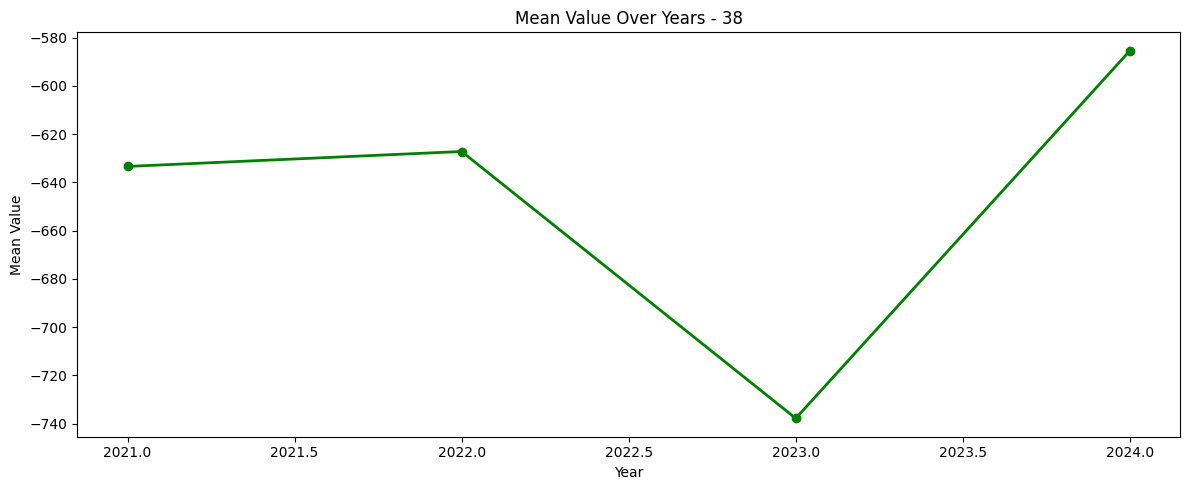

In [39]:
top_poll = prefinal_df["Pollutant"].value_counts().head(5).index
dominant = top_poll[0]

fig, ax = plt.subplots(figsize=(12, 5))
sub = prefinal_df[prefinal_df["Pollutant"] == dominant].groupby("Year")["Value"].mean()
ax.plot(sub.index, sub.values, marker="o", linewidth=2, color="green")
ax.set_title(f"Mean Value Over Years - {dominant}")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Value")
plt.tight_layout()
plt.show()

Mean value over time - others

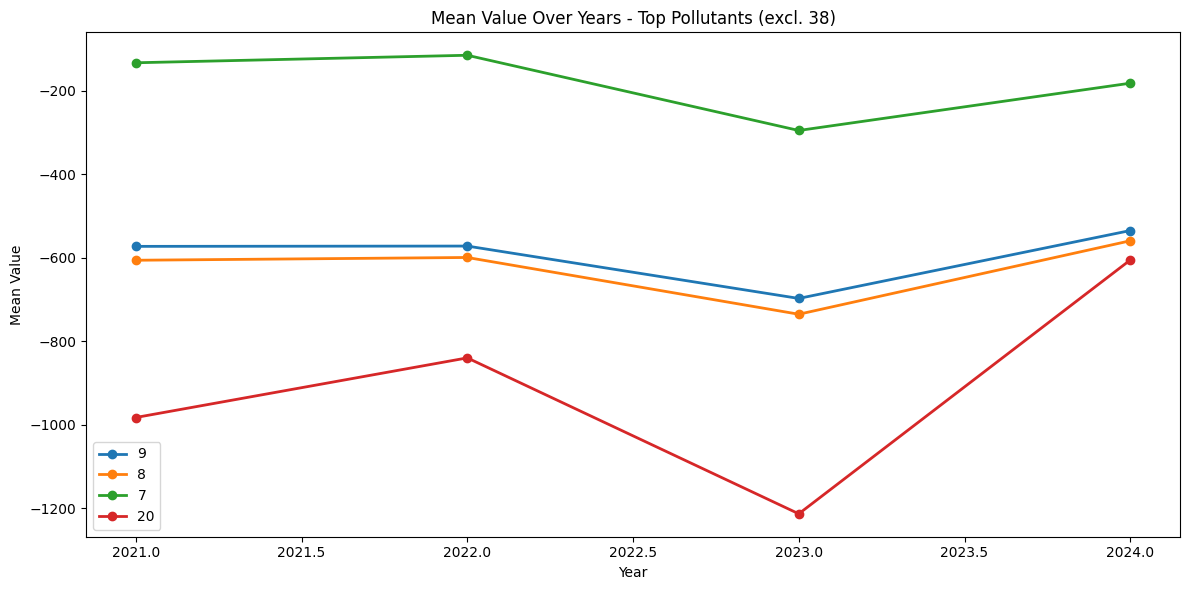

In [40]:
others = [p for p in top_poll if p != dominant]
if others:
    fig, ax = plt.subplots(figsize=(12, 6))
    for poll in others:
        sub = prefinal_df[prefinal_df["Pollutant"] == poll].groupby("Year")["Value"].mean()
        ax.plot(sub.index, sub.values, marker="o", linewidth=2, label=poll)
    ax.set_title(f"Mean Value Over Years - Top Pollutants (excl. {dominant})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Value")
    ax.legend()
    plt.tight_layout()
    plt.show()


### Value Distribution by Pollutant (valid data only)

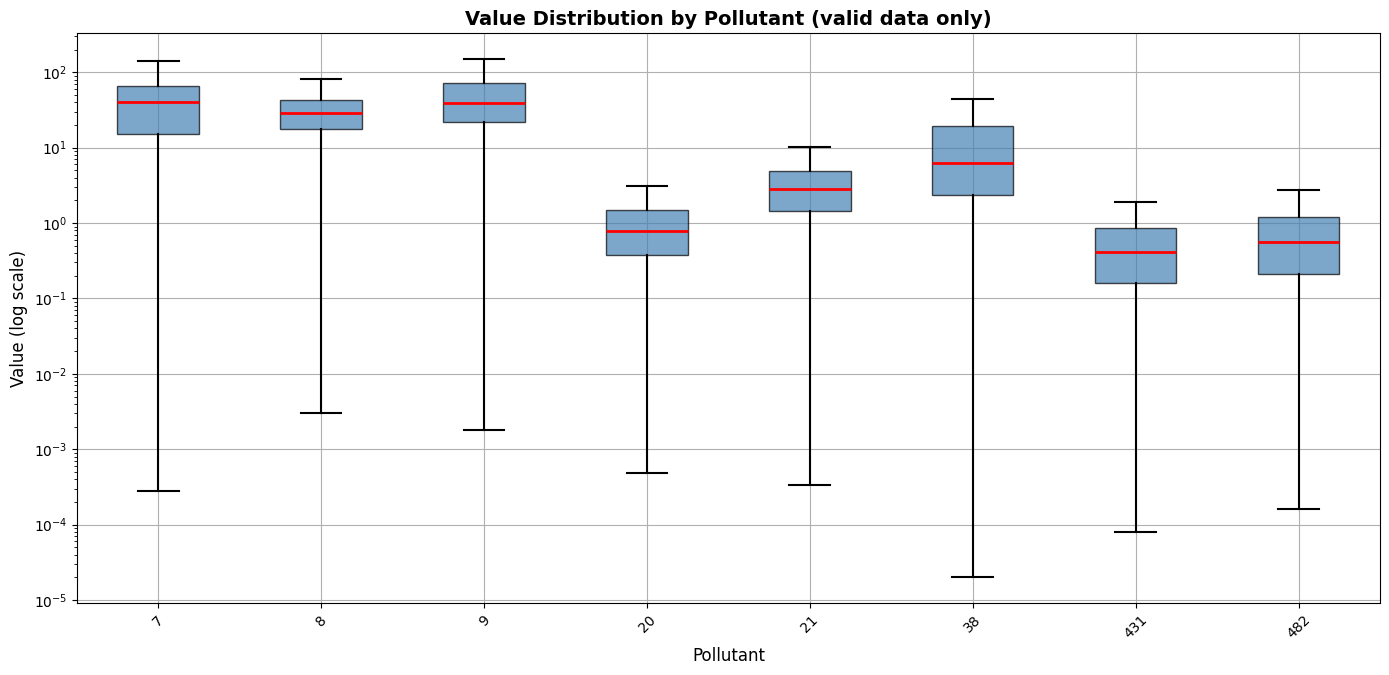

In [41]:
top8 = prefinal_df["Pollutant"].value_counts().head(8).index
subset = prefinal_df[(prefinal_df["Pollutant"].isin(top8)) &
                      (prefinal_df["Value"] > 0)]

fig, ax = plt.subplots(figsize=(14, 7))
subset.boxplot(column="Value", by="Pollutant", ax=ax, rot=45,
               showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="red", linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5))
ax.set_yscale("log")
ax.set_title("Value Distribution by Pollutant (valid data only)", fontsize=14, fontweight="bold")
ax.set_xlabel("Pollutant", fontsize=12)
ax.set_ylabel("Value (log scale)", fontsize=12)
plt.suptitle("")
plt.tight_layout()
plt.show()

## Zero & Negative Values

In [42]:
zero_count = (prefinal_df["Value"] == 0).sum()
neg_count = (prefinal_df["Value"] < 0).sum()
null_count = prefinal_df["Value"].isna().sum()
print(f"  Zeros: {zero_count:,} ({zero_count/len(prefinal_df)*100:.2f}%)")
print(f"  Negatives: {neg_count:,} ({neg_count/len(prefinal_df)*100:.2f}%)")
print(f"  Nulls: {null_count:,} ({null_count/len(prefinal_df)*100:.2f}%)")

if neg_count > 0:
    print(f"\n  Min negative value: {prefinal_df['Value'].min()}")
    print(f"  Negatives by pollutant:")
    negs = prefinal_df[prefinal_df["Value"] < 0]
    print(negs["Pollutant"].value_counts())


  Zeros: 65,296 (3.42%)
  Negatives: 133,558 (6.99%)
  Nulls: 0 (0.00%)

  Min negative value: -9999.0
  Negatives by pollutant:
Pollutant
38     25352
8      23037
9      22784
20      9584
482     9358
21      9286
464     9246
431     9243
1       8253
7       5251
10      2164
Name: count, dtype: int64


### Zeros by pollutant

In [43]:
for poll in prefinal_df["Pollutant"].unique():
    sub = prefinal_df[prefinal_df["Pollutant"] == poll]
    zeros = (sub["Value"] == 0).sum()
    negs = (sub["Value"] < 0).sum()
    nulls = sub["Value"].isna().sum()
    total = len(sub)
    print(f"  Pollutant {poll}: zeros={zeros:,} ({zeros/total*100:.1f}%) | "
          f"negatives={negs:,} ({negs/total*100:.1f}%) | "
          f"nulls={nulls:,} ({nulls/total*100:.1f}%) | total={total:,}")

# Check: are negatives very small (sensor noise) or large?
negs = prefinal_df[prefinal_df["Value"] < 0]
if len(negs) > 0:
    print(f"\n=== NEGATIVE VALUES ===")
    print(f"Count: {len(negs):,}")
    print(f"Range: {negs['Value'].min():.4f} to {negs['Value'].max():.4f}")
    print(f"\nDistribution:")
    print(negs["Value"].describe())

  Pollutant 20: zeros=6,370 (6.1%) | negatives=9,584 (9.1%) | nulls=0 (0.0%) | total=105,192
  Pollutant 21: zeros=1,033 (1.0%) | negatives=9,286 (8.8%) | nulls=0 (0.0%) | total=105,192
  Pollutant 38: zeros=2,848 (0.8%) | negatives=25,352 (7.2%) | nulls=0 (0.0%) | total=350,640
  Pollutant 431: zeros=27,717 (26.3%) | negatives=9,243 (8.8%) | nulls=0 (0.0%) | total=105,192
  Pollutant 464: zeros=6,381 (6.1%) | negatives=9,246 (8.8%) | nulls=0 (0.0%) | total=105,192
  Pollutant 482: zeros=20,419 (19.4%) | negatives=9,358 (8.9%) | nulls=0 (0.0%) | total=105,192
  Pollutant 8: zeros=39 (0.0%) | negatives=23,037 (6.6%) | nulls=0 (0.0%) | total=350,640
  Pollutant 9: zeros=22 (0.0%) | negatives=22,784 (6.5%) | nulls=0 (0.0%) | total=350,640
  Pollutant 10: zeros=0 (0.0%) | negatives=2,164 (3.1%) | nulls=0 (0.0%) | total=70,128
  Pollutant 1: zeros=22 (0.0%) | negatives=8,253 (15.7%) | nulls=0 (0.0%) | total=52,584
  Pollutant 7: zeros=445 (0.2%) | negatives=5,251 (2.5%) | nulls=0 (0.0%) | t



> Are zeros happening at specific hours? (sensor downtime = midnight/maintenance?)



In [44]:
prefinal_df["Hour"] = pd.to_datetime(prefinal_df["Start"]).dt.hour
zeros = prefinal_df[prefinal_df["Value"] == 0]

print("Zeros by hour:")
print(zeros["Hour"].value_counts().sort_index())

print("\nZeros by Validity flag:")
print(zeros["Validity"].value_counts())

print("\nNon-zero data by Validity flag:")
valid_data = prefinal_df[(prefinal_df["Value"] > 0)]
print(valid_data["Validity"].value_counts())



Zeros by hour:
Hour
0     2592
1     2733
2     2899
3     3221
4     3706
5     3535
6     2754
7     2127
8     1782
9     1869
10    2076
11    2440
12    2801
13    3183
14    3425
15    3454
16    3201
17    2943
18    2597
19    2310
20    2306
21    2375
22    2418
23    2549
Name: count, dtype: int64

Zeros by Validity flag:
Validity
2    65296
Name: count, dtype: int64

Non-zero data by Validity flag:
Validity
1    1595145
2     116977
Name: count, dtype: int64


## Duplicates

In [45]:
print(f"Exact duplicate rows: {prefinal_df.duplicated().sum()}")
print(f"Duplicates by Samplingpoint + Start: {prefinal_df.duplicated(subset=['Samplingpoint', 'Start']).sum()}")
print(f"Duplicates by Samplingpoint + Start + Pollutant: {prefinal_df.duplicated(subset=['Samplingpoint', 'Start', 'Pollutant']).sum()}")

Exact duplicate rows: 0
Duplicates by Samplingpoint + Start: 0
Duplicates by Samplingpoint + Start + Pollutant: 0


## Data Quality Summary

In [46]:
print(f"  Total rows: {len(prefinal_df):,}")
print(f"  Columns: {prefinal_df.shape[1]}")
print(f"  Columns with nulls: {(prefinal_df.isna().sum() > 0).sum()}")
print(f"  Exact duplicates: {prefinal_df.duplicated().sum()}")
print(f"  Unique sampling points: {prefinal_df['Samplingpoint'].nunique()}")
print(f"  Unique pollutants: {prefinal_df['Pollutant'].nunique()}")
print(f"  Year range: {prefinal_df['Year'].min()} - {prefinal_df['Year'].max()}")
print(f"  Value range: {prefinal_df['Value'].min()} to {prefinal_df['Value'].max()}")
print(f"  Zero values: {(prefinal_df['Value'] == 0).sum():,}")
print(f"  Negative values: {(prefinal_df['Value'] < 0).sum():,}")

  Total rows: 1,910,976
  Columns: 14
  Columns with nulls: 1
  Exact duplicates: 0
  Unique sampling points: 55
  Unique pollutants: 11
  Year range: 2021 - 2024
  Value range: -9999.0 to 1135.98413
  Zero values: 65,296
  Negative values: 133,558


Mapping all air quality stations from df_stats with their location info
--
Shows: station name, coordinates, altitude, and what pollutants they measure


In [48]:
DF_STATS_PATH = "/content/df_stats.csv"

df = df_stats

# Group by station: get location + list of pollutants
stations = df.groupby("Air Quality Station Name").agg({
    "Latitude": "first",
    "Longitude": "first",
    "Altitude": "first",
    "Sampling Point Id": "nunique",
    "Pollutant": lambda x: list(x.unique()),
    "Year": lambda x: f"{x.min()}-{x.max()}",
}).reset_index()

stations.columns = [
    "Station", "Lat", "Lon", "Altitude",
    "Num_SamplingPoints", "Pollutants", "Year_Range"
]

stations = stations.sort_values("Station").reset_index(drop=True)

print(f"Total unique stations: {len(stations)}\n")

for _, row in stations.iterrows():
    print(f"Station: {row['Station']}")
    print(f"  Coordinates: {row['Lat']}, {row['Lon']}")
    print(f"  Altitude: {row['Altitude']}m")
    print(f"  Sampling Points: {row['Num_SamplingPoints']}")
    print(f"  Pollutants: {row['Pollutants']}")
    print(f"  Years: {row['Year_Range']}")
    print()

# Also show the geographic spread
print("=" * 50)
print("GEOGRAPHIC SPREAD:")
print(f"  Lat range: {stations['Lat'].min()} - {stations['Lat'].max()}")
print(f"  Lon range: {stations['Lon'].min()} - {stations['Lon'].max()}")

# Distance between furthest stations (rough km)
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

max_dist = 0
for i, r1 in stations.iterrows():
    for j, r2 in stations.iterrows():
        d = haversine(r1['Lat'], r1['Lon'], r2['Lat'], r2['Lon'])
        if d > max_dist:
            max_dist = d
            pair = (r1['Station'], r2['Station'])

print(f"  Max distance between stations: {max_dist:.1f} km ({pair[0]} <-> {pair[1]})")
print(f"  Altitude range: {stations['Altitude'].min()}m - {stations['Altitude'].max()}m")

Total unique stations: 10

Station: ARENULA
  Coordinates: 41.894, 12.4754
  Altitude: 17.0m
  Sampling Points: 4
  Pollutants: ['NO', 'NO2', 'NOX as NO2', 'O3']
  Years: 2021-2024

Station: BUFALOTTA
  Coordinates: 41.9477, 12.5337
  Altitude: 36.0m
  Sampling Points: 5
  Pollutants: ['O3', 'NO2', 'NOX as NO2', 'SO2', 'NO']
  Years: 2021-2024

Station: C.SO FRANCIA
  Coordinates: 41.9474, 12.4696
  Altitude: 35.0m
  Sampling Points: 8
  Pollutants: ['C6H6', 'NO', 'C6H5-C2H5', 'm,p-C6H4(CH3)2', 'NO2', 'NOX as NO2', 'C6H5-CH3', 'o-C6H4-(CH3)2']
  Years: 2021-2024

Station: CINECITTA
  Coordinates: 41.8577, 12.5687
  Altitude: 48.0m
  Sampling Points: 4
  Pollutants: ['NO2', 'NOX as NO2', 'NO', 'O3']
  Years: 2021-2024

Station: CIPRO
  Coordinates: 41.9064, 12.4476
  Altitude: 24.0m
  Sampling Points: 4
  Pollutants: ['NO', 'O3', 'NO2', 'NOX as NO2']
  Years: 2021-2024

Station: FERMI
  Coordinates: 41.864, 12.4696
  Altitude: 17.0m
  Sampling Points: 9
  Pollutants: ['NO', 'm,p-C6H4(CH

#parquet table cleaning

- Drop 'AggType' — not useful for analysis
- Drop 'ResultTime' — only 4 unique values, not informative
- Drop 'DataCapture' — 100% NaN, no data
- Drop 'FkObservationLog' — not useful for analysis

In [ ]:
prefinal_df = prefinal_df.drop(columns=["AggType", "ResultTime", "DataCapture", "FkObservationLog"])

print(f"Remaining columns: {prefinal_df.shape[1]}")
print(prefinal_df.columns.tolist())

- Remove 'IT/' prefix from Samplingpoint in prefinal_df to match df_stats format
- df_stats uses: SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00
- prefinal_df uses: IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00

In [ ]:
prefinal_df["Samplingpoint"] = prefinal_df["Samplingpoint"].str.replace("IT/", "", n=1)

# Verify
print("Prefinal sample:", prefinal_df["Samplingpoint"].iloc[0])

- Replace ALL Validity=2 values with NaN — Validity 2 means "not valid/unreliable"
- This covers zeros, negatives, and any other values flagged as invalid

In [ ]:

v2_count = (prefinal_df["Validity"] == 2).sum()

prefinal_df.loc[prefinal_df["Validity"] == 2, "Value"] = np.nan

print(f"Validity=2 values replaced: {v2_count:,}")
print(f"Total NaN in Value now: {prefinal_df['Value'].isna().sum():,}")

 Replacing any remaining negative values with NaN — sensor noise/artifacts

In [ ]:
remaining_neg = (prefinal_df["Value"] < 0).sum()

prefinal_df.loc[prefinal_df["Value"] < 0, "Value"] = np.nan

print(f"Remaining negatives replaced: {remaining_neg:,}")
print(f"Total NaN in Value now: {prefinal_df['Value'].isna().sum():,}")

- Drop 'Unit Of Air Pollution Level' — unit info already in prefinal_df's 'Unit' column
- Drop 'Air Pollution Level' — aggregated stat, prefinal_df has the actual hourly values

In [ ]:
df_stats = df_stats.drop(columns=["Unit Of Air Pollution Level", "Air Pollution Level"])

print(f"Remaining columns: {df_stats.shape[1]}")
print(df_stats.columns.tolist())

In [49]:
prefinal_df.head()

,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog,Year,Hour
52608,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 00:00:00,2021-01-01 01:00:00,2.34,ug.m-3,hour,1,1,2022-09-12 15:14:28,NaN,b5b6d257-9b4f-4183-983d-8494a3e866e7,2021,0
52609,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 01:00:00,2021-01-01 02:00:00,-9999.00,ug.m-3,hour,-1,1,2022-09-12 15:14:28,NaN,b5b6d257-9b4f-4183-983d-8494a3e866e7,2021,1
52610,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 02:00:00,2021-01-01 03:00:00,2.32,ug.m-3,hour,1,1,2022-09-12 15:14:28,NaN,b5b6d257-9b4f-4183-983d-8494a3e866e7,2021,2
52611,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 03:00:00,2021-01-01 04:00:00,2.05,ug.m-3,hour,1,1,2022-09-12 15:14:28,NaN,b5b6d257-9b4f-4183-983d-8494a3e866e7,2021,3
52612,IT/SPO.IT0825A_20_GC-PID_2006-07-26_00:00:00,20,2021-01-01 04:00:00,2021-01-01 05:00:00,1.76,ug.m-3,hour,1,1,2022-09-12 15:14:28,NaN,b5b6d257-9b4f-4183-983d-8494a3e866e7,2021,4


In [50]:
# Check df_stats: same Samplingpoint + Year, different pollutants
stats_grouped = df_stats.groupby(["Sampling Point Id", "Year"])["Pollutant"].nunique().reset_index()
stats_multi = stats_grouped[stats_grouped["Pollutant"] > 1]
print("df_stats:")
print(f"  Total Samplingpoint+Year groups: {len(stats_grouped)}")
print(f"  Groups with multiple pollutants: {len(stats_multi)}")

# Check prefinal_df: same Samplingpoint + Year, different pollutants
pf_grouped = prefinal_df.groupby(["Samplingpoint", "Year"])["Pollutant"].nunique().reset_index()
pf_multi = pf_grouped[pf_grouped["Pollutant"] > 1]
print("\nprefinal_df:")
print(f"  Total Samplingpoint+Year groups: {len(pf_grouped)}")
print(f"  Groups with multiple pollutants: {len(pf_multi)}")

# Show examples if any
if len(pf_multi) > 0:
    print("\nPrefinal examples:")
    for _, row in pf_multi.head(3).iterrows():
        sp = row["Samplingpoint"]
        yr = row["Year"]
        sub = prefinal_df[(prefinal_df["Samplingpoint"] == sp) & (prefinal_df["Year"] == yr)]
        print(f"  {sp} | Year: {yr} | Pollutant: {sub['Pollutant'].unique()}")

df_stats:
  Total Samplingpoint+Year groups: 218
  Groups with multiple pollutants: 0

prefinal_df:
  Total Samplingpoint+Year groups: 218
  Groups with multiple pollutants: 0


- Drop Pollutant_code from prefinal_df — each Samplingpoint+Year already maps to one pollutant
- Pollutant name will come from df_stats after merging on Samplingpoint + Year

In [51]:

prefinal_df = prefinal_df.drop(columns=["Pollutant"])

print(f"Remaining columns: {prefinal_df.columns.tolist()}")

Remaining columns: ['Samplingpoint', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog', 'Year', 'Hour']


In [52]:
df_stats = df_stats.rename(columns={"Sampling Point Id": "Samplingpoint"})

print("Done. Column renamed to 'Samplingpoint'")

Done. Column renamed to 'Samplingpoint'


In [53]:
dupes = df_stats.duplicated(subset=["Samplingpoint", "Year"], keep=False)
print(f"Duplicate Samplingpoint+Year in df_stats: {dupes.sum()}")

# Show an example
example = df_stats[df_stats.duplicated(subset=["Samplingpoint", "Year"], keep=False)]
sp = example["Samplingpoint"].iloc[0]
yr = example["Year"].iloc[0]
print(f"\nExample: {sp} | Year: {yr}")
print(df_stats[(df_stats["Samplingpoint"] == sp) & (df_stats["Year"] == yr)])

Duplicate Samplingpoint+Year in df_stats: 2706

Example: SPO.IT1835A_7_UV-P_2006-12-06_00:00:00 | Year: 2021
    Air Quality Station Name                           Samplingpoint  \
0                  BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
1                  BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
118                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
120                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
154                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
155                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
157                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
164                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
180                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
181                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
182                BUFALOTTA  SPO.IT1835A_7_UV-P_2006-12-06_00:00:00   
183                BUFALOTT

In [54]:
# Check before
print(f"Before: {len(df_stats):,} rows")

df_stats = df_stats.drop(columns=["Data Aggregation Process Id", "Data Aggregation Process"])
df_stats = df_stats.drop_duplicates()

print(f"After: {len(df_stats):,} rows")

# Verify: each Samplingpoint+Year should now have exactly 1 row
check = df_stats.groupby(["Samplingpoint", "Year"]).size()
print(f"Max rows per Samplingpoint+Year: {check.max()}")

Before: 2,706 rows
After: 2,422 rows
Max rows per Samplingpoint+Year: 29


In [55]:
# Drop Calculation Time and Link — differ per aggregation type, not needed for analysis
df_stats = df_stats.drop(columns=[

    "Link to raw data (only E1a/validated data from AQ e-Reporting)"
])

# Now deduplicate
df_stats = df_stats.drop_duplicates()

print(f"After: {len(df_stats):,} rows")
check = df_stats.groupby(["Samplingpoint", "Year"]).size()
print(f"Max rows per Samplingpoint+Year: {check.max()}")

After: 2,422 rows
Max rows per Samplingpoint+Year: 29


In [56]:
import gc
gc.collect()

print(f"prefinal_df: {len(prefinal_df):,} rows")
print(f"df_stats: {len(df_stats):,} rows")

df_merged = pd.merge(
    prefinal_df,
    df_stats,
    on=["Samplingpoint", "Year"],
    how="left",
    suffixes=("", "_stats"),
)

print(f"Merged: {len(df_merged):,} rows — should equal prefinal_df rows")
print(f"Columns: {df_merged.columns.tolist()}")

prefinal_df: 1,910,976 rows
df_stats: 2,422 rows
Merged: 1,910,976 rows — should equal prefinal_df rows
Columns: ['Samplingpoint', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog', 'Year', 'Hour', 'Air Quality Station Name', 'Pollutant', 'Air Pollutant Description', 'Air Pollution Level', 'Unit Of Air Pollution Level', 'Longitude', 'Latitude', 'Altitude']


In [65]:
df_merged

In [66]:
df_merged.describe()

AttributeError: 'NoneType' object has no attribute 'describe'

In [69]:
df_merged = pd.read_csv("df_merged_stats_parquet_pre.csv")

In [71]:
from google.colab import files
files.download("df_merged_stats_parquet_pre.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>